# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Nguyễn Văn Thạch"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600237"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://customers-hosted-considered-connection.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 7 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 79.0% | Mem: 11.3/16.0GB | Power: 51W | Temp: 77°C
   GPU 1 [T4] 🔴 Util: 70.5% | Mem: 14.0/16.0GB | Power: 49W | Temp: 64°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 86.1% | Mem: 40.0/80.0GB | Power: 200W | Temp: 80°C
   GPU 1 [A100] 🔴 Util: 70.6% | Mem: 58.3/80.0GB | Power: 275W | Temp: 75°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 65.6% | Mem: 17.8/32.0GB | Power: 243W | Temp: 67°C
   GPU 1 [V100] 🟢 Util: 5.6% | Mem: 1.6/32.0GB | Power: 49W | Temp: 42°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 84.9% | Mem: 14.0/16.0GB | Power: 47W | Temp: 77°C
   GPU 1 [T4] 🔴 Util: 78.3% | Mem: 11.8/16.0GB | Power: 62W | Temp: 66°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 63.9% | Mem: 11.2/16.0GB | Power: 44W | Temp: 66°C
   GPU 1 [T4] 🔴 Util: 92.5% | Mem: 8.5/16.0GB | Power: 48W | Temp: 72°C

🖥️  node-05:
   GPU 0 [T4] 🟢 Util: 1.7% | Mem: 1.8/16.0GB | Power: 34W | Temp: 44°C
   GPU 1 [T4] 🟢 Util: 9.8% | Mem: 1.8/16.0GB | Power: 24W | Temp: 44°C

🖥️  node-06:


In [5]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          14
Busy GPUs:           9
Idle GPUs:           5
Avg Utilization:     50.6%
Memory Used:         193.0 GB
Memory Capacity:     384.0 GB
Total Power Draw:    1166 W
Node Count:          7


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-05', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-05', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-06', 'gpu_id': 0}, {'node_id': 'node-06', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 14/14 | Utilization: 78.8%


In [7]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $3.9229
   Total Savings:  $4.1229
   Budget Used:    3.9%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2718     22.3    % high
A100       $3.67       $2.0816     43.3    % low
V100       $2.48       $1.8681     24.7    % high


In [9]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 6

💰 Spot Savings Report:
   Spot cost:        $0.0425
   On-demand equiv:  $0.1416
   Total saved:      $0.0991 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 78.8% > threshold 70.0%
   Current utilization: 78.8%
   Nodes: 7 → 8

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 68.9% | Nodes: 8→8
   Cycle 2: no_action    | Util: 68.9% | Nodes: 8→8
   Cycle 3: no_action    | Util: 68.9% | Nodes: 8→8
   Cycle 4: no_action    | Util: 68.9% | Nodes: 8→8
   Cycle 5: no_action    | Util: 68.9% | Nodes: 8→8


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 2: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 3: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 4: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 5: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%


In [14]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.4%
   Total Idle Cost:        $0.019440
   Total Cost:             $0.440830
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 16 GPUs across 8 nodes
   Utilization: 68.9% | Busy: 14 | Idle: 2

💰 BILLING: $3.9229 / $100.00 budget
   Alert: OK | Savings: $4.1229

🎯 SPOT: Saved $0.1220 (70.0%)

🗑️  WASTE: 4.4% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

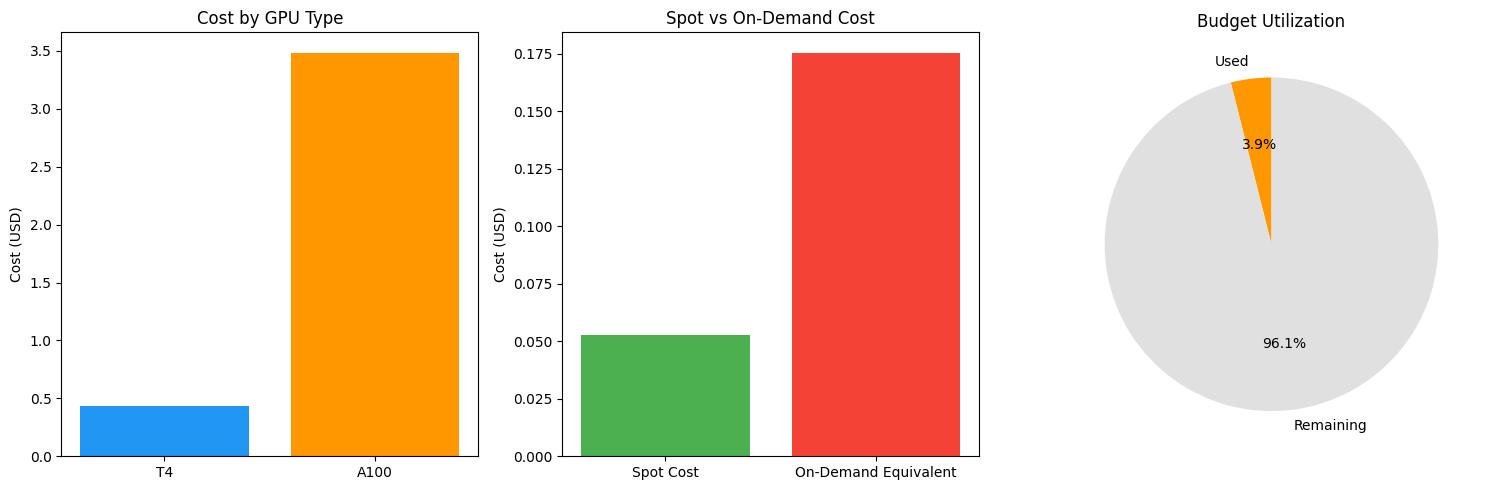

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


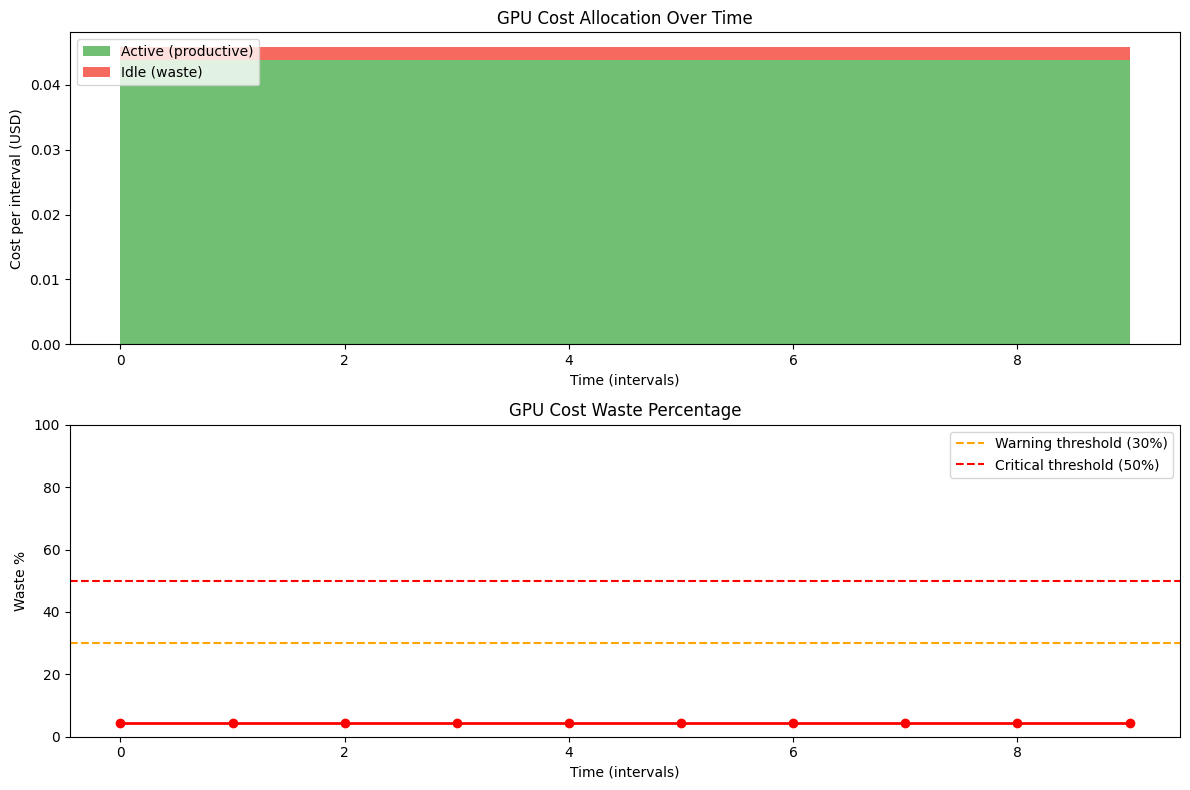

In [18]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 16 | Util: 68.9% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 78.7% | Busy: 16/16

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 78.7% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.047778
   Waste: 4.1%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0398 (70.0%)

7️⃣  Final billing:
   Total spend: $4.0920
   Total saved: $4.2453
   Budget: 4.1% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install lightweight dependency and detect real GPU
# Important: On Kaggle/Colab, do NOT blindly reinstall torch/torchvision.
# The preinstalled build is usually matched to the runtime GPU/driver.
!pip install -q pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_props = torch.cuda.get_device_properties(0)
gpu_mem = gpu_props.total_memory / 1e9
device_capability = torch.cuda.get_device_capability(0)
device_sm = f"sm_{device_capability[0]}{device_capability[1]}"
compiled_arches = torch.cuda.get_arch_list()

# Fast compatibility check: ensure this PyTorch build includes kernels for the current GPU.
if device_sm not in compiled_arches and f"compute_{device_capability[0]}{device_capability[1]}" not in compiled_arches:
    install_hint = ""
    if device_sm == "sm_60":
        install_hint = (
            "\nP100 detected (sm_60). Your current torch build dropped sm_60 kernels. "
            "If a clean runtime still fails, try an older official PyTorch wheel, for example:\n"
            "pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 "
            "--index-url https://download.pytorch.org/whl/cu118"
        )
    raise RuntimeError(
        f"Incompatible PyTorch CUDA build for this GPU. GPU={gpu_name} ({device_sm}), "
        f"but torch was compiled for {compiled_arches}. Restart the runtime and use the "
        f"preinstalled torch build first, or install a compatible build from "
        f"https://docs.pytorch.org/get-started/previous-versions/.{install_hint}"
    )

# Tiny smoke test to fail early before the long training cells.
try:
    _smoke_x = torch.randn(2, 3, 8, 8, device="cuda")
    _smoke_bn = nn.BatchNorm2d(3).cuda()
    _ = _smoke_bn(_smoke_x)
    del _smoke_x, _smoke_bn, _
    torch.cuda.synchronize()
    print("CUDA smoke test: OK")
except Exception as e:
    raise RuntimeError(
        "CUDA runtime is visible, but a basic kernel test failed. This usually means the "
        "installed torch wheel does not match the runtime GPU architecture. Restart the runtime "
        "and avoid reinstalling torch/torchvision in this notebook. Original error: "
        f"{e}"
    )

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print("Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   Device capability: {device_capability} -> {device_sm}")
print(f"   Torch architectures: {compiled_arches}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

CUDA smoke test: OK
Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   Device capability: (7, 5) -> sm_75
   Torch architectures: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
   pynvml:  available


In [22]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=602/16106 MB
   Power: 28.4W
   Temp: 49C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 602.079232
   mem_util_pct: 0.0
   power_watts: 28.443
   temp_c: 49.0

   Method: pynvml

Ready for training.


In [23]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 81.0MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [24]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.9643 | Acc: 30.0% | Time: 41.2s | Samples: 40
   Epoch 2/3 | Loss: 1.4152 | Acc: 48.0% | Time: 43.6s | Samples: 40
   Epoch 3/3 | Loss: 1.1285 | Acc: 60.1% | Time: 46.7s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      131.5s
   Peak memory:     0.82 GB
   Avg GPU util:    94.4%
   Avg power:       66.3W
   Avg temperature: 70.9C
   Max GPU util:    98.0%
   Estimated cost:  $0.012788


In [25]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8701 | Acc: 32.1% | Time: 20.5s | Samples: 40
   Epoch 2/3 | Loss: 1.3004 | Acc: 52.5% | Time: 20.3s | Samples: 40
   Epoch 3/3 | Loss: 0.9636 | Acc: 65.7% | Time: 20.5s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      61.4s
   Peak memory:     0.60 GB
   Avg GPU util:    88.6%
   Avg power:       65.5W
   Avg temperature: 76.6C
   Max GPU util:    93.0%
   Estimated cost:  $0.005971


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                131.5           61.4            2.14x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012788       $0.005971       $0.006817 saved
Cost Saving %             ---             ---             53.3%
Avg GPU Util %            94.4            88.6           
Avg Power (W)             66.3            65.5           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.92 -> SAVE $4.48
   1 week training: FP32=$58.80 vs AMP=$27.45 -> SAVE $31.35
   1 month training: FP32=$252.00 vs AMP=$117.66 -> SAVE $134.34


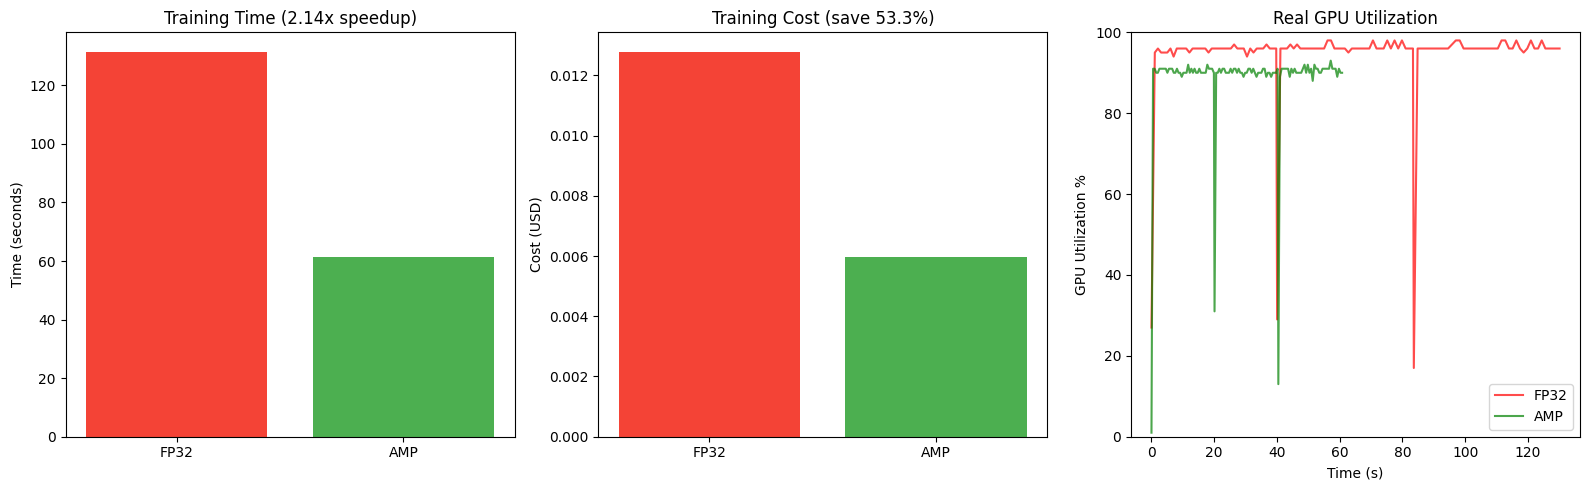

In [26]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012800 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001800 | Saved: $0.004200

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.029200
   Total Savings:   $0.008400
   Workloads:       4

   Cost snapshot taken: waste=14.4%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $4.0920
   Total Savings:        $4.2453
   Budget Utilization:   4.1%
   Alert:                OK


Real GPU Telemetry During Training


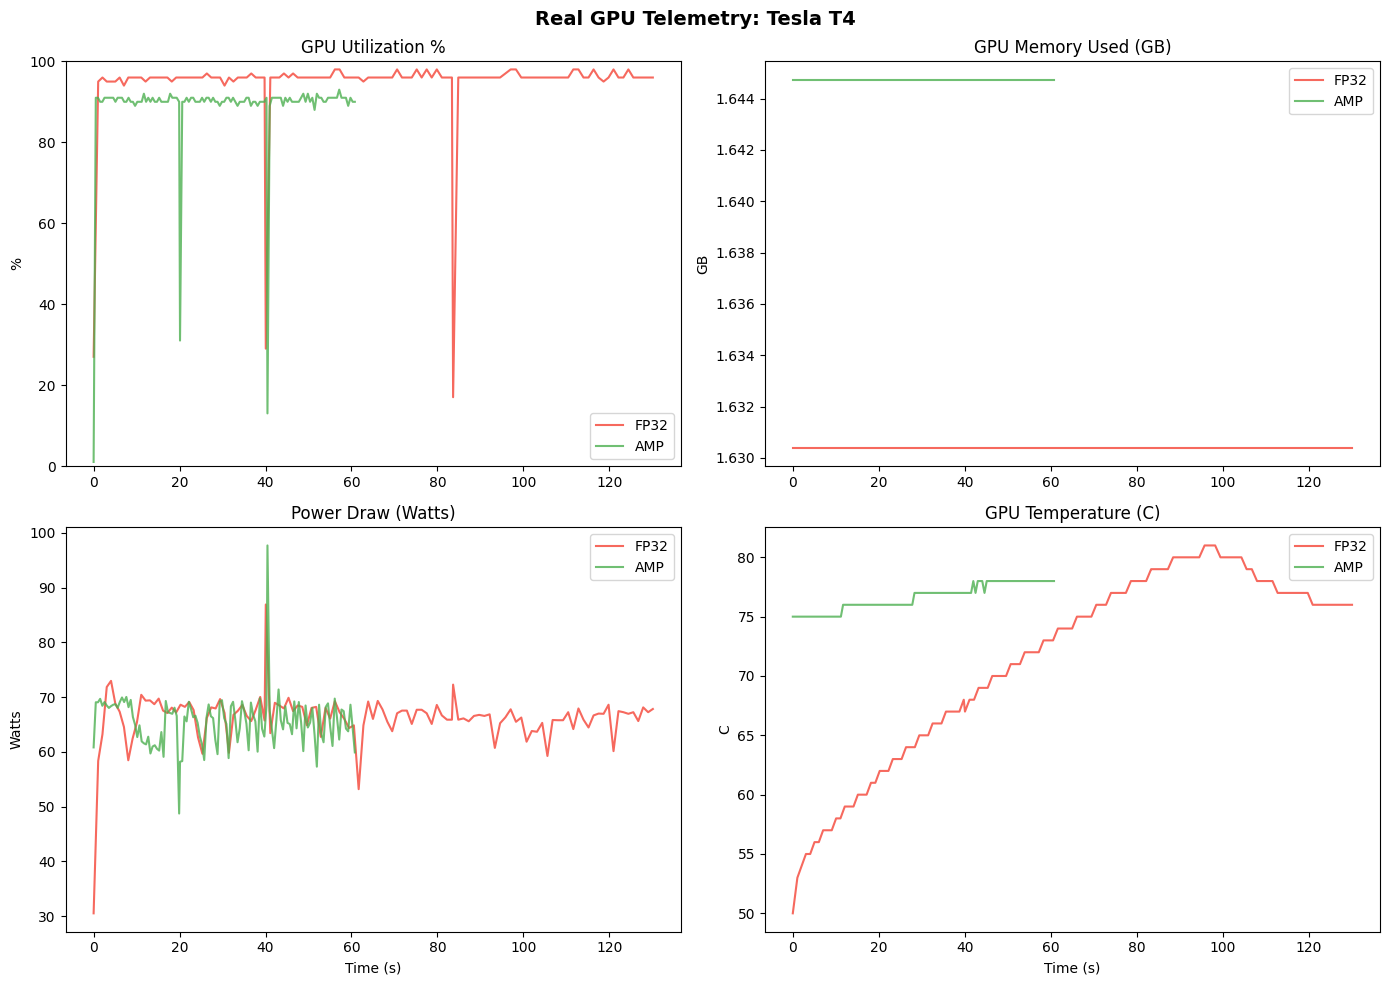

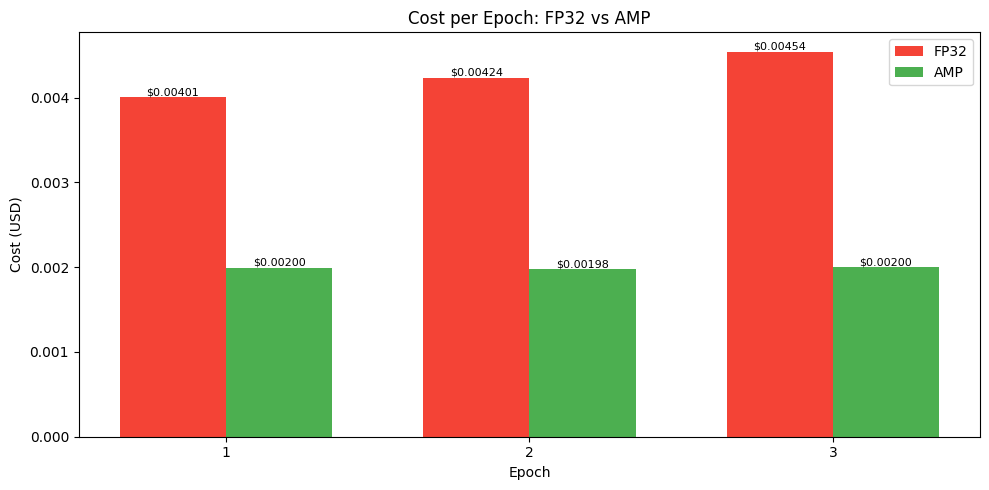


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [29]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU type used for analysis: T4
 gpu_count  speedup_factor  scaling_efficiency_pct  time_hours  total_cost_usd  cost_multiplier_vs_1gpu  usd_per_speedup_unit
         1             1.0                   100.0       2.000          0.7000                    1.000                0.7000
         2             1.8                    90.0       1.111          0.7778                    1.111                0.4321
         4             3.2                    80.0       0.625          0.8750                    1.250                0.2734
         8             5.6                    70.0       0.357          1.0000                    1.429                0.1786

✅ Best raw cost option: {'gpu_count': 1, 'speedup_factor': 1.0, 'scaling_efficiency_pct': 100.0, 'time_hours': 2.0, 'total_cost_usd': 0.7, 'cost_multiplier_vs_1gpu': 1.0, 'usd_per_speedup_unit': 0.7}
✅ Best cost/performance option: {'gpu_count': 8, 'speedup_factor': 5.6, 'scaling_efficiency_pct':

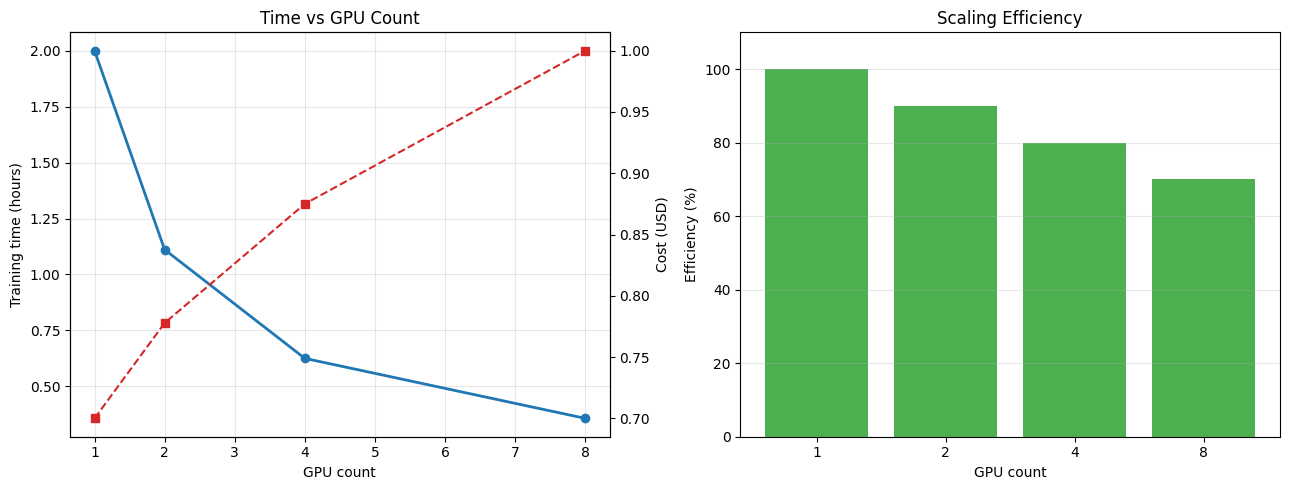

📊 Chart saved as multi_gpu_scaling.png


In [30]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# More GPUs improve time-to-result, but scaling is usually sub-linear.
def _default_scaling_factor(gpu_count):
    lookup = {1: 1.0, 2: 1.8, 4: 3.2, 8: 5.6, 16: 10.4}
    if gpu_count in lookup:
        return lookup[gpu_count]
    return round(gpu_count ** 0.85, 2)


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """Analyze multi-GPU time, cost, and scaling efficiency."""
    price_per_hour = GPU_PRICING[gpu_type]
    scaling_factors = scaling_factors or {
        count: _default_scaling_factor(count) for count in gpu_counts
    }

    baseline_cost = base_time_hours * price_per_hour
    rows = []

    for gpu_count in gpu_counts:
        speedup = scaling_factors.get(gpu_count, _default_scaling_factor(gpu_count))
        efficiency = speedup / gpu_count
        time_hours = base_time_hours / speedup
        total_cost = time_hours * price_per_hour * gpu_count
        cost_multiplier = total_cost / baseline_cost if baseline_cost else 0
        usd_per_speedup_unit = total_cost / speedup if speedup else float("inf")

        rows.append({
            "gpu_count": gpu_count,
            "speedup_factor": round(speedup, 2),
            "scaling_efficiency_pct": round(efficiency * 100, 2),
            "time_hours": round(time_hours, 3),
            "total_cost_usd": round(total_cost, 4),
            "cost_multiplier_vs_1gpu": round(cost_multiplier, 3),
            "usd_per_speedup_unit": round(usd_per_speedup_unit, 4),
        })

    best_cost = min(rows, key=lambda row: row["total_cost_usd"])
    best_efficiency = min(rows, key=lambda row: row["usd_per_speedup_unit"])
    fastest = min(rows, key=lambda row: row["time_hours"])

    return {
        "gpu_type": gpu_type,
        "base_time_hours": base_time_hours,
        "price_per_hour": price_per_hour,
        "scaling_factors": scaling_factors,
        "results": rows,
        "best_cost_option": best_cost,
        "best_efficiency_option": best_efficiency,
        "fastest_option": fastest,
    }

# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]
analysis_gpu_type = globals().get("detected_type", "A100")

multi_gpu_analysis = analyze_multi_gpu_cost(
    base_time_hours=base_training_time,
    gpu_type=analysis_gpu_type,
    gpu_counts=test_gpu_counts,
)

multi_gpu_df = pd.DataFrame(multi_gpu_analysis["results"])
print(f"\nGPU type used for analysis: {analysis_gpu_type}")
print(multi_gpu_df.to_string(index=False))

print("\n✅ Best raw cost option:", multi_gpu_analysis["best_cost_option"])
print("✅ Best cost/performance option:", multi_gpu_analysis["best_efficiency_option"])
print("✅ Fastest option:", multi_gpu_analysis["fastest_option"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(multi_gpu_df["gpu_count"], multi_gpu_df["time_hours"], marker="o", linewidth=2, label="Training time")
axes[0].set_title("Time vs GPU Count")
axes[0].set_xlabel("GPU count")
axes[0].set_ylabel("Training time (hours)")
axes[0].grid(alpha=0.3)

ax0b = axes[0].twinx()
ax0b.plot(multi_gpu_df["gpu_count"], multi_gpu_df["total_cost_usd"], marker="s", linestyle="--", color="tab:red")
ax0b.set_ylabel("Cost (USD)")

axes[1].bar(multi_gpu_df["gpu_count"].astype(str), multi_gpu_df["scaling_efficiency_pct"], color="#4CAF50")
axes[1].set_title("Scaling Efficiency")
axes[1].set_xlabel("GPU count")
axes[1].set_ylabel("Efficiency (%)")
axes[1].set_ylim(0, 110)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as multi_gpu_scaling.png")

EXERCISE 8.5.2: Project Cost Forecasting
                 name gpu_type  gpu_count  duration_hours  rate_per_hour  base_cost_usd  uncertainty_pct  uncertainty_usd
     Data Preparation       T4          1              40           0.35           14.0             15.0             2.10
       Model Training     A100          4             120           3.67         1761.6             25.0           440.40
Hyperparameter Tuning     A100          8              60           3.67         1761.6             30.0           528.48
     Model Evaluation       T4          2              20           0.35           14.0             10.0             1.40

Expected total with contingency: $4261.44
Best case:  $2578.82
Worst case: $5233.82
95% confidence interval: $3573.51 to $4949.37


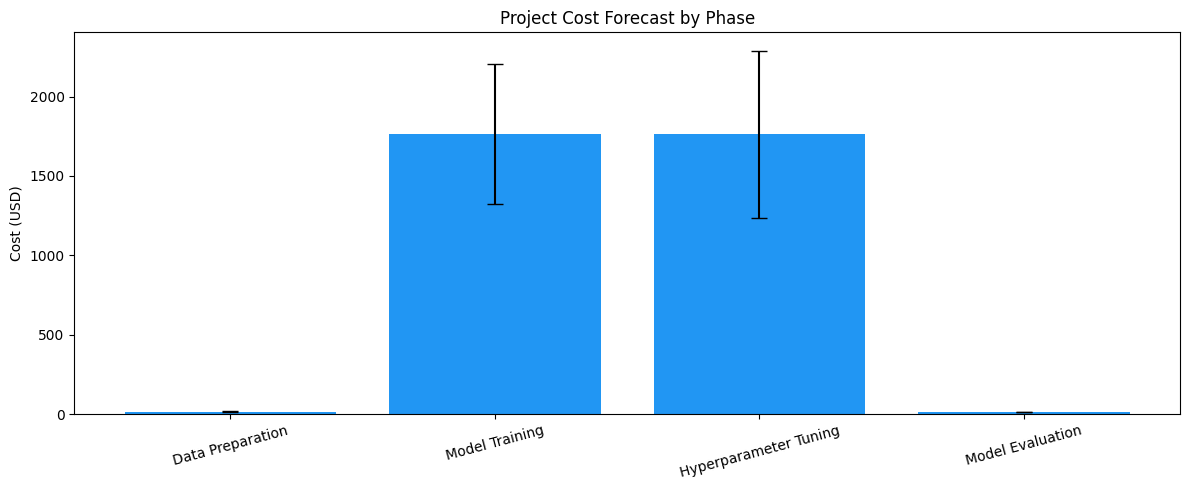

📊 Chart saved as project_forecast.png


In [31]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math


def _z_score(confidence_level):
    z_map = {0.80: 1.282, 0.90: 1.645, 0.95: 1.960, 0.99: 2.576}
    nearest = min(z_map, key=lambda item: abs(item - confidence_level))
    return z_map[nearest]


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """Forecast multi-phase project cost with uncertainty and contingency."""
    z = _z_score(confidence_level)
    contingency_ratio = contingency_pct / 100 if contingency_pct > 1 else contingency_pct

    phase_rows = []
    for phase in phases:
        rate = GPU_PRICING[phase["gpu_type"]]
        base_cost = rate * phase["gpu_count"] * phase["duration_hours"]
        uncertainty_usd = base_cost * phase["uncertainty_pct"]
        phase_rows.append({
            "name": phase["name"],
            "gpu_type": phase["gpu_type"],
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "rate_per_hour": rate,
            "base_cost_usd": round(base_cost, 2),
            "uncertainty_pct": round(phase["uncertainty_pct"] * 100, 1),
            "uncertainty_usd": round(uncertainty_usd, 2),
        })

    total_base = sum(row["base_cost_usd"] for row in phase_rows)
    total_uncertainty = sum(row["uncertainty_usd"] for row in phase_rows)
    combined_uncertainty = math.sqrt(sum(row["uncertainty_usd"] ** 2 for row in phase_rows))
    contingency_cost = total_base * contingency_ratio
    expected_total = total_base + contingency_cost
    ci_margin = combined_uncertainty * (z / 1.96)

    return {
        "confidence_level": confidence_level,
        "z_score": z,
        "phases": phase_rows,
        "total_base_cost_usd": round(total_base, 2),
        "contingency_pct": contingency_pct,
        "contingency_cost_usd": round(contingency_cost, 2),
        "expected_total_with_contingency_usd": round(expected_total, 2),
        "best_case_usd": round(max(total_base - total_uncertainty, 0), 2),
        "worst_case_usd": round(total_base + contingency_cost + total_uncertainty, 2),
        "ci_lower_usd": round(max(expected_total - ci_margin, 0), 2),
        "ci_upper_usd": round(expected_total + ci_margin, 2),
        "combined_uncertainty_usd": round(combined_uncertainty, 2),
    }

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
project_df = pd.DataFrame(project_forecast["phases"])
print(project_df.to_string(index=False))

print(f"\nExpected total with contingency: ${project_forecast['expected_total_with_contingency_usd']:.2f}")
print(f"Best case:  ${project_forecast['best_case_usd']:.2f}")
print(f"Worst case: ${project_forecast['worst_case_usd']:.2f}")
print(f"95% confidence interval: ${project_forecast['ci_lower_usd']:.2f} to ${project_forecast['ci_upper_usd']:.2f}")

plt.figure(figsize=(12, 5))
plt.bar(project_df["name"], project_df["base_cost_usd"], color="#2196F3")
plt.errorbar(project_df["name"], project_df["base_cost_usd"], yerr=project_df["uncertainty_usd"], fmt="none", ecolor="black", capsize=6)
plt.title("Project Cost Forecast by Phase")
plt.ylabel("Cost (USD)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis
                             name  savings_pct  potential_savings_usd implementation_effort risk_level dependencies  priority_score  implementation_order  cumulative_savings_usd  cumulative_savings_pct roadmap_stage
  Switch to Mixed Precision (AMP)         25.0                  367.0                   LOW        LOW           []          367.00                     1                  367.00                   25.00     Quick win
               Use Spot Instances         60.0                  880.8                MEDIUM       HIGH           []          220.20                     2                 1027.60                   70.00     Strategic
              Optimize Batch Size         15.0                  220.2                   LOW        LOW           []          220.20                     3                 1093.66                   74.50     Quick win
         Implement Early Stopping         20.0                  293.6        

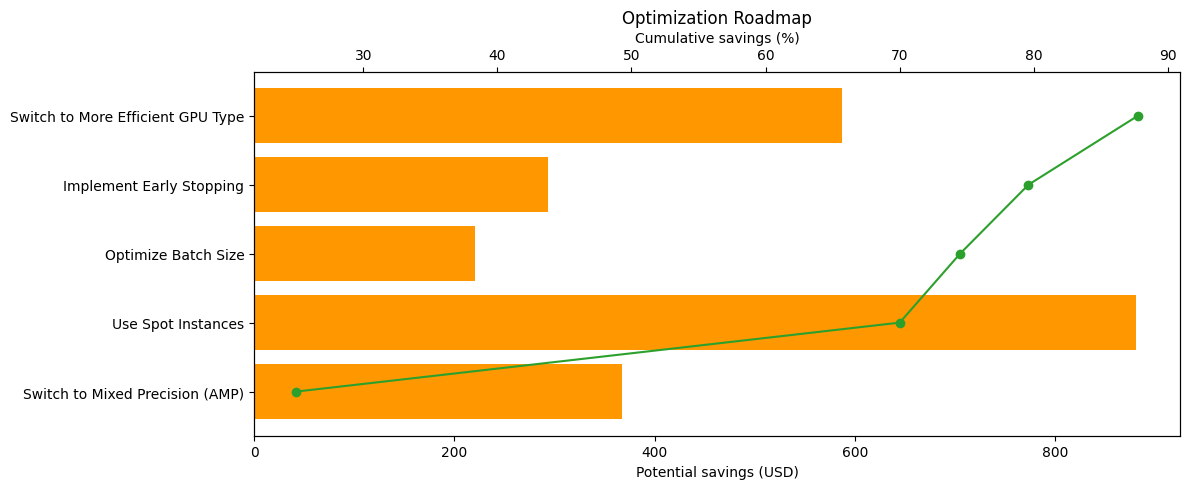

📊 Chart saved as optimization_roadmap.png


In [33]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

EFFORT_WEIGHT = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
RISK_WEIGHT = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}


def analyze_optimization_opportunities(current_config, optimization_strategies):
    """Prioritize optimization strategies by savings, effort, and risk."""
    price_per_hour = GPU_PRICING[current_config["gpu_type"]]
    baseline_cost = price_per_hour * current_config["gpu_count"] * current_config["duration_hours"]

    prioritized = []
    for strategy in optimization_strategies:
        savings_ratio = strategy["savings_pct"] if strategy["savings_pct"] <= 1 else strategy["savings_pct"] / 100
        effort = EFFORT_WEIGHT[strategy["implementation_effort"]]
        risk = RISK_WEIGHT[strategy["risk_level"]]
        dependency_penalty = 0.85 if strategy["dependencies"] else 1.0
        potential_savings = baseline_cost * savings_ratio
        priority_score = (potential_savings / (effort * (1 + 0.5 * (risk - 1)))) * dependency_penalty

        prioritized.append({
            "name": strategy["name"],
            "savings_pct": round(savings_ratio * 100, 1),
            "potential_savings_usd": round(potential_savings, 2),
            "implementation_effort": strategy["implementation_effort"],
            "risk_level": strategy["risk_level"],
            "dependencies": strategy["dependencies"],
            "priority_score": round(priority_score, 2),
        })

    prioritized.sort(key=lambda row: row["priority_score"], reverse=True)

    remaining_cost = baseline_cost
    for index, row in enumerate(prioritized, start=1):
        remaining_cost *= 1 - (row["savings_pct"] / 100)
        row["implementation_order"] = index
        row["cumulative_savings_usd"] = round(baseline_cost - remaining_cost, 2)
        row["cumulative_savings_pct"] = round((1 - remaining_cost / baseline_cost) * 100, 2)

        if row["implementation_effort"] == "LOW" and row["risk_level"] == "LOW":
            row["roadmap_stage"] = "Quick win"
        elif row["implementation_effort"] == "HIGH" or row["risk_level"] == "HIGH":
            row["roadmap_stage"] = "Strategic"
        else:
            row["roadmap_stage"] = "Next"

    return {
        "baseline_cost_usd": round(baseline_cost, 2),
        "prioritized": prioritized,
        "projected_remaining_cost_usd": round(remaining_cost, 2),
        "total_projected_savings_usd": round(baseline_cost - remaining_cost, 2),
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
optimization_df = pd.DataFrame(optimization_recommendations["prioritized"])
print(optimization_df.to_string(index=False))

print(f"\nBaseline cost: ${optimization_recommendations['baseline_cost_usd']:.2f}")
print(f"Projected remaining cost: ${optimization_recommendations['projected_remaining_cost_usd']:.2f}")
print(f"Projected total savings: ${optimization_recommendations['total_projected_savings_usd']:.2f}")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.barh(optimization_df["name"], optimization_df["potential_savings_usd"], color="#FF9800")
ax1.set_xlabel("Potential savings (USD)")
ax1.set_title("Optimization Roadmap")

ax2 = ax1.twiny()
ax2.plot(optimization_df["cumulative_savings_pct"], optimization_df["name"], "o-", color="tab:green")
ax2.set_xlabel("Cumulative savings (%)")

plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as optimization_roadmap.png")

EXERCISE 8.5.4: Integrated Cost Dashboard


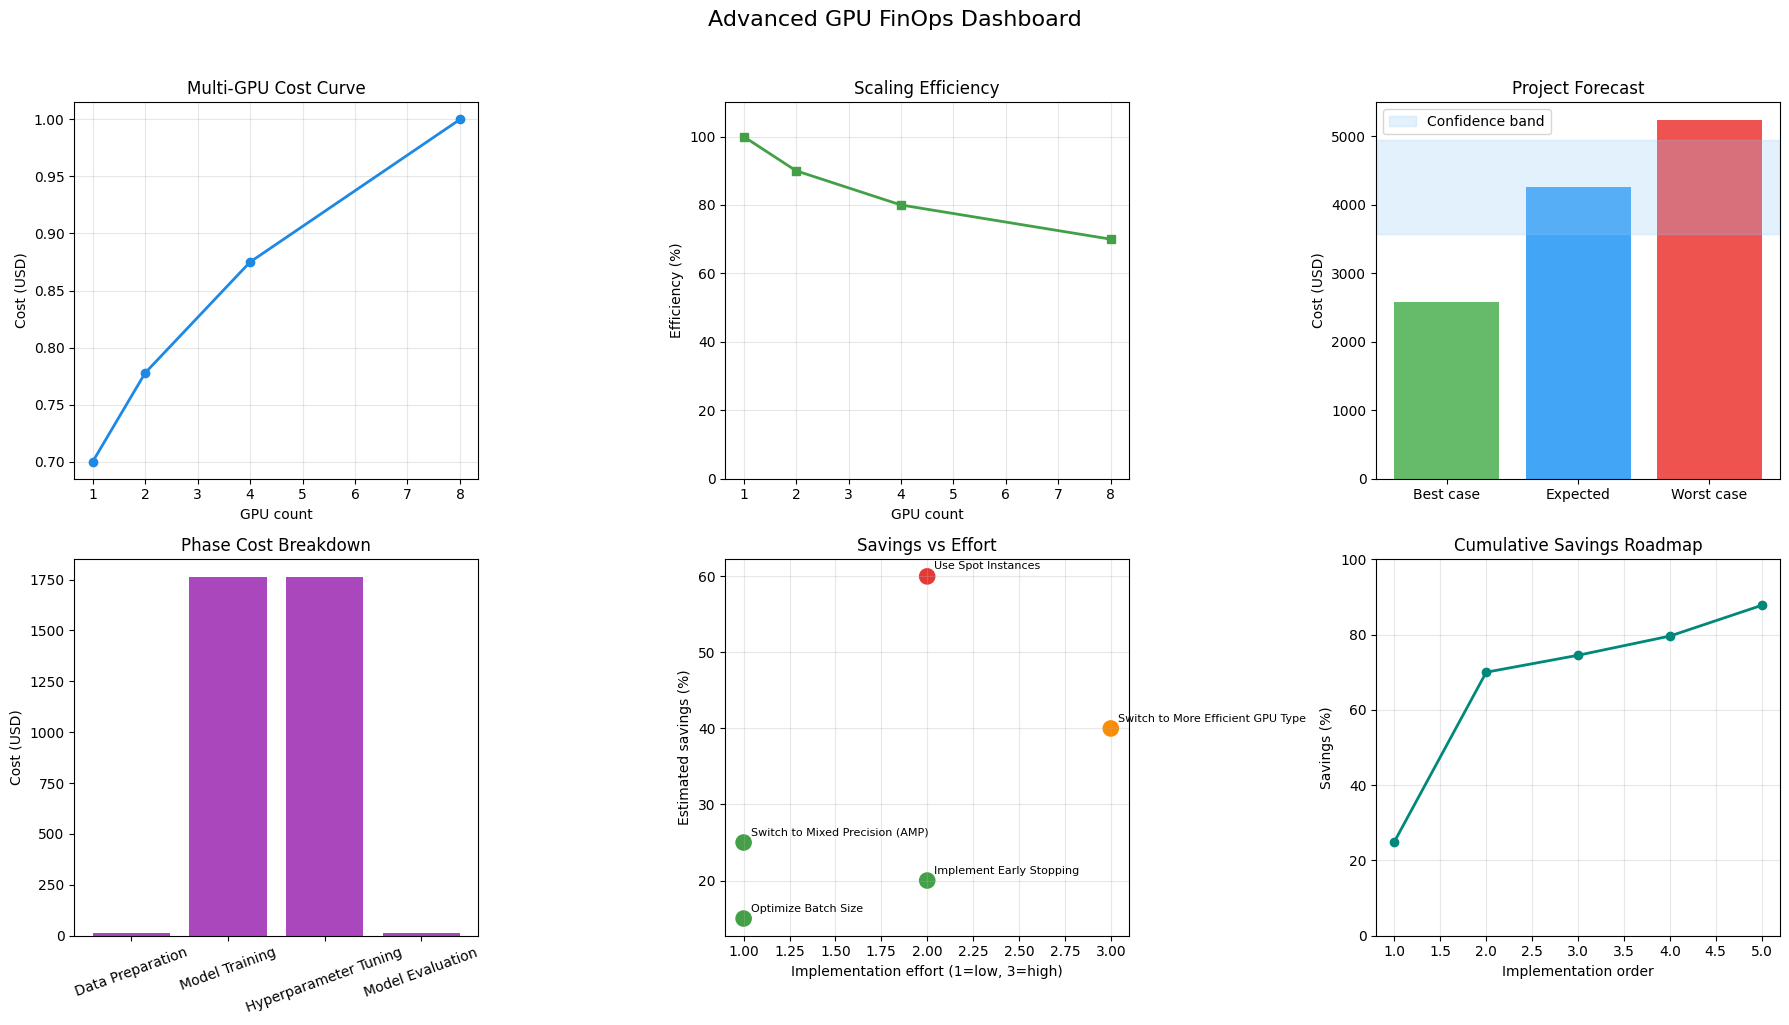

📊 Chart saved as advanced_finops_dashboard.png


In [34]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """Create a 6-panel advanced FinOps dashboard."""
    multi_df = pd.DataFrame(multi_gpu_analysis["results"])
    phase_df = pd.DataFrame(project_forecast["phases"])
    opt_df = pd.DataFrame(optimization_recommendations["prioritized"])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(multi_df["gpu_count"], multi_df["total_cost_usd"], marker="o", linewidth=2, color="#1E88E5")
    axes[0, 0].set_title("Multi-GPU Cost Curve")
    axes[0, 0].set_xlabel("GPU count")
    axes[0, 0].set_ylabel("Cost (USD)")
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(multi_df["gpu_count"], multi_df["scaling_efficiency_pct"], marker="s", linewidth=2, color="#43A047")
    axes[0, 1].set_title("Scaling Efficiency")
    axes[0, 1].set_xlabel("GPU count")
    axes[0, 1].set_ylabel("Efficiency (%)")
    axes[0, 1].set_ylim(0, 110)
    axes[0, 1].grid(alpha=0.3)

    forecast_values = [
        project_forecast["best_case_usd"],
        project_forecast["expected_total_with_contingency_usd"],
        project_forecast["worst_case_usd"],
    ]
    axes[0, 2].bar(["Best case", "Expected", "Worst case"], forecast_values, color=["#66BB6A", "#42A5F5", "#EF5350"])
    axes[0, 2].axhspan(project_forecast["ci_lower_usd"], project_forecast["ci_upper_usd"], color="#90CAF9", alpha=0.25, label="Confidence band")
    axes[0, 2].set_title("Project Forecast")
    axes[0, 2].set_ylabel("Cost (USD)")
    axes[0, 2].legend()

    axes[1, 0].bar(phase_df["name"], phase_df["base_cost_usd"], color="#AB47BC")
    axes[1, 0].set_title("Phase Cost Breakdown")
    axes[1, 0].set_ylabel("Cost (USD)")
    axes[1, 0].tick_params(axis="x", rotation=20)

    effort_numeric = opt_df["implementation_effort"].map(EFFORT_WEIGHT)
    risk_colors = opt_df["risk_level"].map({"LOW": "#43A047", "MEDIUM": "#FB8C00", "HIGH": "#E53935"})
    axes[1, 1].scatter(effort_numeric, opt_df["savings_pct"], s=120, c=risk_colors)
    for _, row in opt_df.iterrows():
        axes[1, 1].annotate(
            row["name"],
            (EFFORT_WEIGHT[row["implementation_effort"]], row["savings_pct"]),
            fontsize=8,
            xytext=(5, 5),
            textcoords="offset points",
        )
    axes[1, 1].set_title("Savings vs Effort")
    axes[1, 1].set_xlabel("Implementation effort (1=low, 3=high)")
    axes[1, 1].set_ylabel("Estimated savings (%)")
    axes[1, 1].grid(alpha=0.3)

    axes[1, 2].plot(opt_df["implementation_order"], opt_df["cumulative_savings_pct"], marker="o", linewidth=2, color="#00897B")
    axes[1, 2].set_title("Cumulative Savings Roadmap")
    axes[1, 2].set_xlabel("Implementation order")
    axes[1, 2].set_ylabel("Savings (%)")
    axes[1, 2].set_ylim(0, 100)
    axes[1, 2].grid(alpha=0.3)

    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, y=1.02)
    plt.tight_layout()
    return fig


dashboard_fig = create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations,
)
dashboard_fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as advanced_finops_dashboard.png")

In [35]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

baseline_gpu_type = challenge_scenario["requirements"]["gpu_type"]
baseline_gpu_count = challenge_scenario["requirements"]["gpu_count"]
baseline_duration = challenge_scenario["requirements"]["training_duration"]
baseline_budget = challenge_scenario["requirements"]["budget"]
deadline_hours = 14 * 24
baseline_hourly_fleet_cost = GPU_PRICING[baseline_gpu_type] * baseline_gpu_count
baseline_cost = baseline_hourly_fleet_cost * baseline_duration

baseline_speedup_at_8 = _default_scaling_factor(baseline_gpu_count)
single_gpu_equivalent_hours = baseline_duration * baseline_speedup_at_8

challenge_multi_gpu = analyze_multi_gpu_cost(
    base_time_hours=single_gpu_equivalent_hours,
    gpu_type=baseline_gpu_type,
    gpu_counts=[4, 6, 8, 12],
)
feasible_options = [row for row in challenge_multi_gpu["results"] if row["time_hours"] <= deadline_hours]
selected_option = min(feasible_options, key=lambda row: row["total_cost_usd"])

allowed_strategies = [
    strategy for strategy in example_strategies
    if strategy["risk_level"] in {"LOW", "MEDIUM"}
]
selected_config = {
    "gpu_type": baseline_gpu_type,
    "gpu_count": selected_option["gpu_count"],
    "duration_hours": selected_option["time_hours"],
    "precision": "FP32",
    "instance_type": "on-demand",
}
challenge_optimization = analyze_optimization_opportunities(selected_config, allowed_strategies)
top_strategies = challenge_optimization["prioritized"][:3]

savings_multiplier = 1.0
for strategy in top_strategies:
    savings_multiplier *= 1 - (strategy["savings_pct"] / 100)

optimized_spend = selected_option["total_cost_usd"] * savings_multiplier
optimized_forecast_low = challenge_optimization["projected_remaining_cost_usd"]
optimized_forecast_high = round(optimized_spend * 1.2, 2)
meets_budget = optimized_spend <= baseline_budget
meets_deadline = selected_option["time_hours"] <= deadline_hours

print(f"\nBaseline cost: ${baseline_cost:.2f}")
print(f"Recommended GPU count: {selected_option['gpu_count']}")
print(f"Estimated training time: {selected_option['time_hours']:.1f}h")
print(f"Cost before optimizations: ${selected_option['total_cost_usd']:.2f}")

print("\nRecommended strategy set:")
for strategy in top_strategies:
    print(
        f"   - {strategy['name']} | save ~{strategy['savings_pct']:.1f}% | "
        f"effort={strategy['implementation_effort']} | risk={strategy['risk_level']}"
    )

print(f"\nProjected optimized spend: ${optimized_spend:.2f}")
print(f"Planning range: ${optimized_forecast_low:.2f} to ${optimized_forecast_high:.2f}")
print(f"Under budget: {meets_budget}")
print(f"Meets deadline: {meets_deadline}")
print(
    "Justification: Choose the lowest-cost GPU count that still meets the 2-week deadline, "
    "avoid high-risk spot usage, and stack low/medium-risk optimizations first."
)

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

Baseline cost: $5872.00
Recommended GPU count: 6
Estimated training time: 244.0h
Cost before optimizations: $5373.07

Recommended strategy set:
   - Switch to Mixed Precision (AMP) | save ~25.0% | effort=LOW | risk=LOW
   - Optimize Batch Size | save ~15.0% | effort=LOW | risk=LOW
   - Implement Early Stopping | save ~20.0% | effort=MEDIUM | risk=LOW

Projected optimized spend: $2740.27
Planning range: $1644.16 to $3288.32
Under budget: True
Meets deadline: True
Justification: Choose the lowest-cost GPU count that still meets the 2-week deadline, avoid high-risk spot usage, and stack low/medium-risk optimizations first.


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend